Легкие 

In [ ]:
# https://coderun.yandex.ru/problem/median-out-of-three/description
# 1. Средний элемент
mas = list(map(int, input().split(' ')))
mas.sort()
print(mas[1])

In [ ]:
# https://coderun.yandex.ru/problem/open-calculator?compiler=python
# 58. OpenCalculator
a = sorted(list(map(str, input().split(' '))))
b = sorted(input())

if set(b).issubset(set(a)):
    print(0)
else:
    print(len(b)-len(a))

In [ ]:
# https://coderun.yandex.ru/problem/three-numbers
# 174. Разные цифры
from itertools import combinations

import sys 

def find_3_number(list):
    for i in combinations(list, 3):
        digits_count = set(''.join(map(str, i)))
        if len(digits_count) == 10:
            return(' '.join(map(str, i)))
    return None 

def main():
    n = int(input())
    for i in range(0,n):
        t = int(input())
        numbers = list(map(int, input().split(' ')))
        print(find_3_number(numbers))

if __name__  == "__main__":
    main()


In [ ]:
# https://coderun.yandex.ru/problem/triangle
# 81. Треугольник
a = int(input())
b = int(input())
c = int(input())

if (a + b > c) and (a + c > b) and (b + c > a):
    print('YES')
else:
    print('NO')

In [ ]:
# https://coderun.yandex.ru/problem/q1-c-text
# 183. Шифр
import codecs
with open('encoded.txt') as f:
    content = f.read()


decoded = codecs.decode(content, 'rot_13')
print(decoded)

with open('deencoded.txt', 'w') as f:
    f.write(decoded)

In [ ]:
# https://coderun.yandex.ru/problem/list-growing
# 72. Возрастает ли список?
a = list(map(int, input().split(' ')))

chek = 'YES'

for i in range(1, len(a)):
    if a[i] - a[i-1] <= 0:
        chek = 'NO'
print(chek)

Средние 

In [ ]:
# https://coderun.yandex.ru/problem/cheapest-way
# 2. Самый дешевый путь
import sys

def main():
    n,m = map(int, input().split(" "))
    t = [list(map(int, input().split(" "))) for _ in range(n)]

    ft = [[0]*m for i in range(n)]    
    ft[0][0] = t[0][0]

    for i in range(1,n):
        ft[i][0] = ft[i-1][0] + t[i][0]

    for j in range(1,m):
        ft[0][j] = ft[0][j-1] + t[0][j]

    for i in range(1,n):
        for j in range(1,m):
            ft[i][j] = min(ft[i-1][j], ft[i][j-1]) + t[i][j]
    result = ft[-1][-1]
    print(result)

if __name__ == '__main__':
    main()



In [ ]:
# https://coderun.yandex.ru/problem/print-the-route-of-the-maximum-cost
# 3. Вывести маршрут максимальной стоимости

import sys

def main():
    n, m = map(int,  input().split())
    t = [list(map(int, input().split())) for i in range(n)]
    ft = [[0]*m for _ in range (n)]
    ft[0][0] = t[0][0]

    def back_step(ft):
        steps = ''
        pointer = [-1,-1]
        for i in range(n+m-2):
            if pointer[0]== -n:
                steps='R' + steps
            elif pointer[1]== -m:
                steps='D' + steps
            elif ft[pointer[0]-1][pointer[1]] >= ft[pointer[0]][pointer[1]-1]:
                steps='D' + steps
                pointer[0] = pointer[0]-1
            else:
                steps='R' + steps
                pointer[1] = pointer[1]-1

        return steps

    for i in range(1, n):
        ft[i][0] = ft[i-1][0] + t[i][0]

    for j in range(1,m):
        ft[0][j] = ft[0][j-1] + t[0][j]

    for i in range(1, n):
        for j in range (1,m):
            ft[i][j] = t[i][j] + max(ft[i-1][j], ft[i][j-1])
    res = ft[-1][-1]
    
    print(res)
    print(back_step(ft))

if __name__ == '__main__':
    main()


стажерский контест 

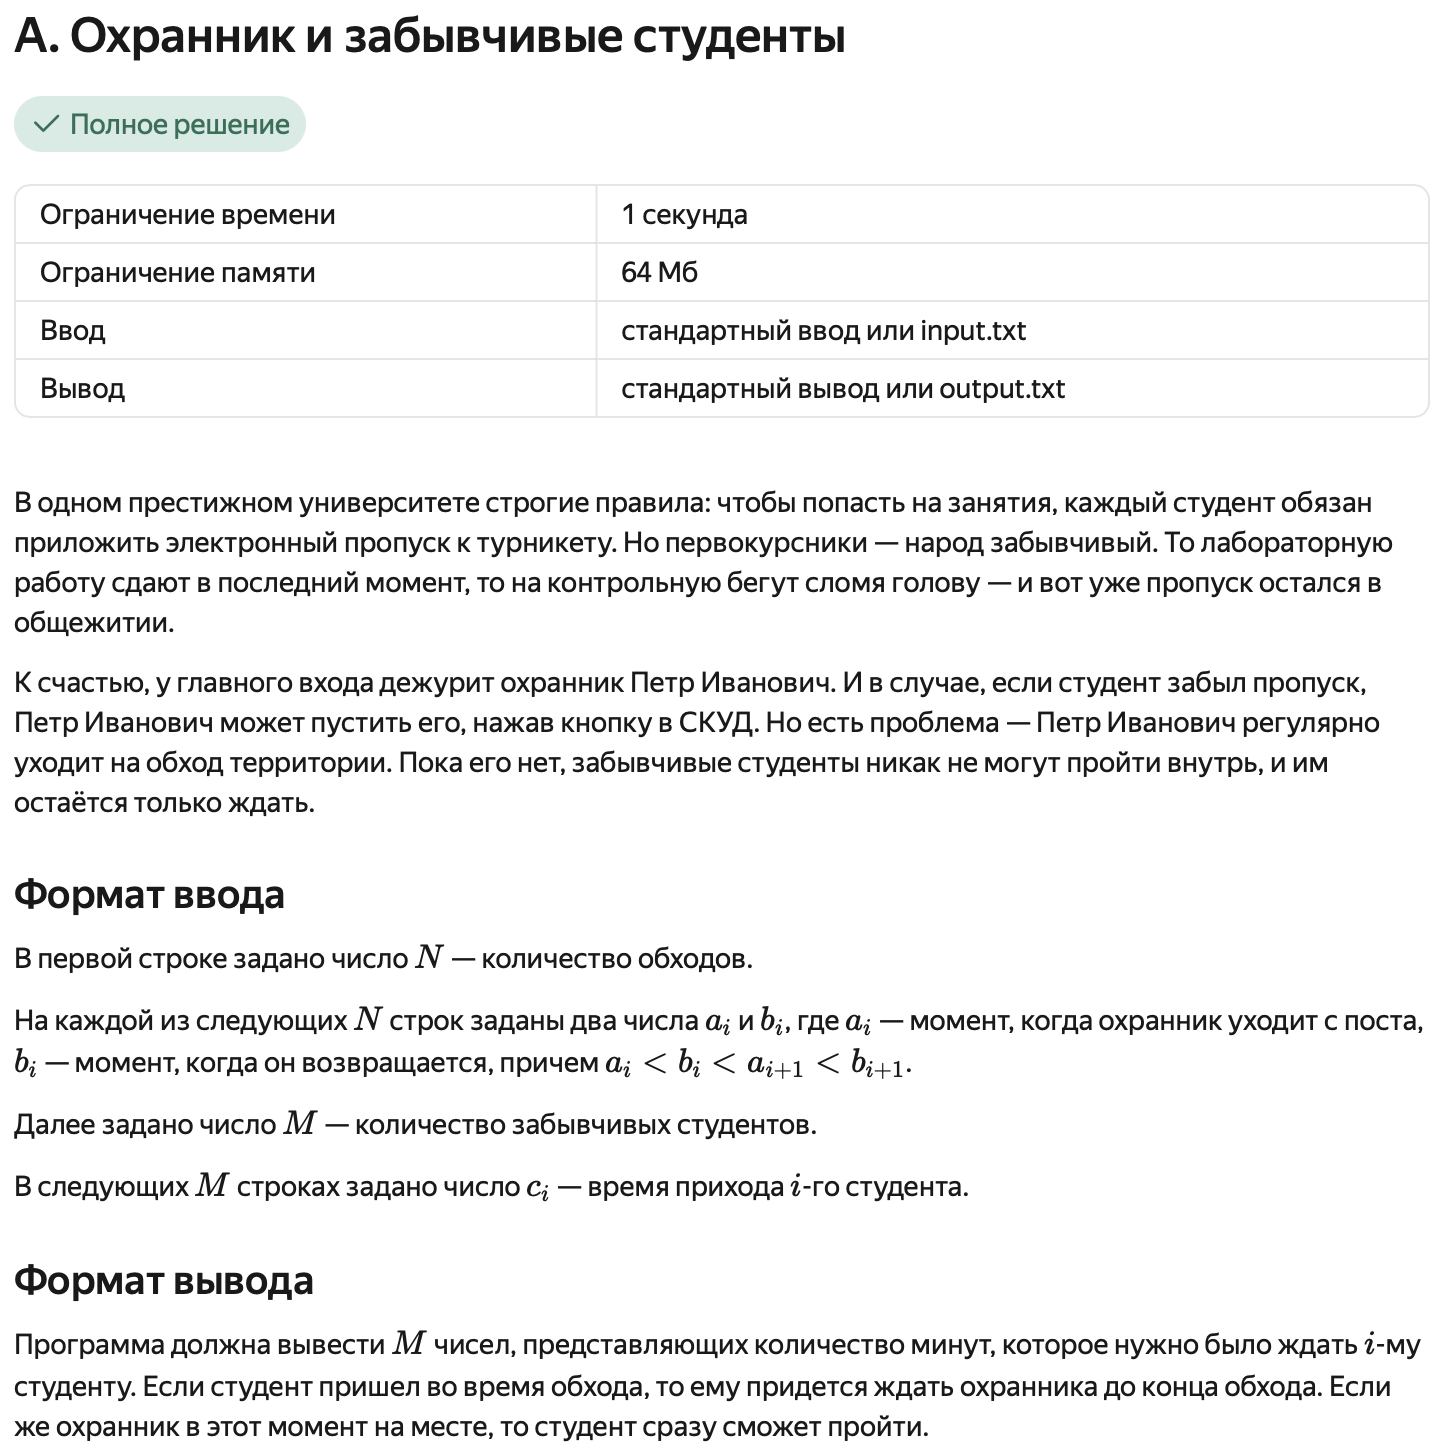

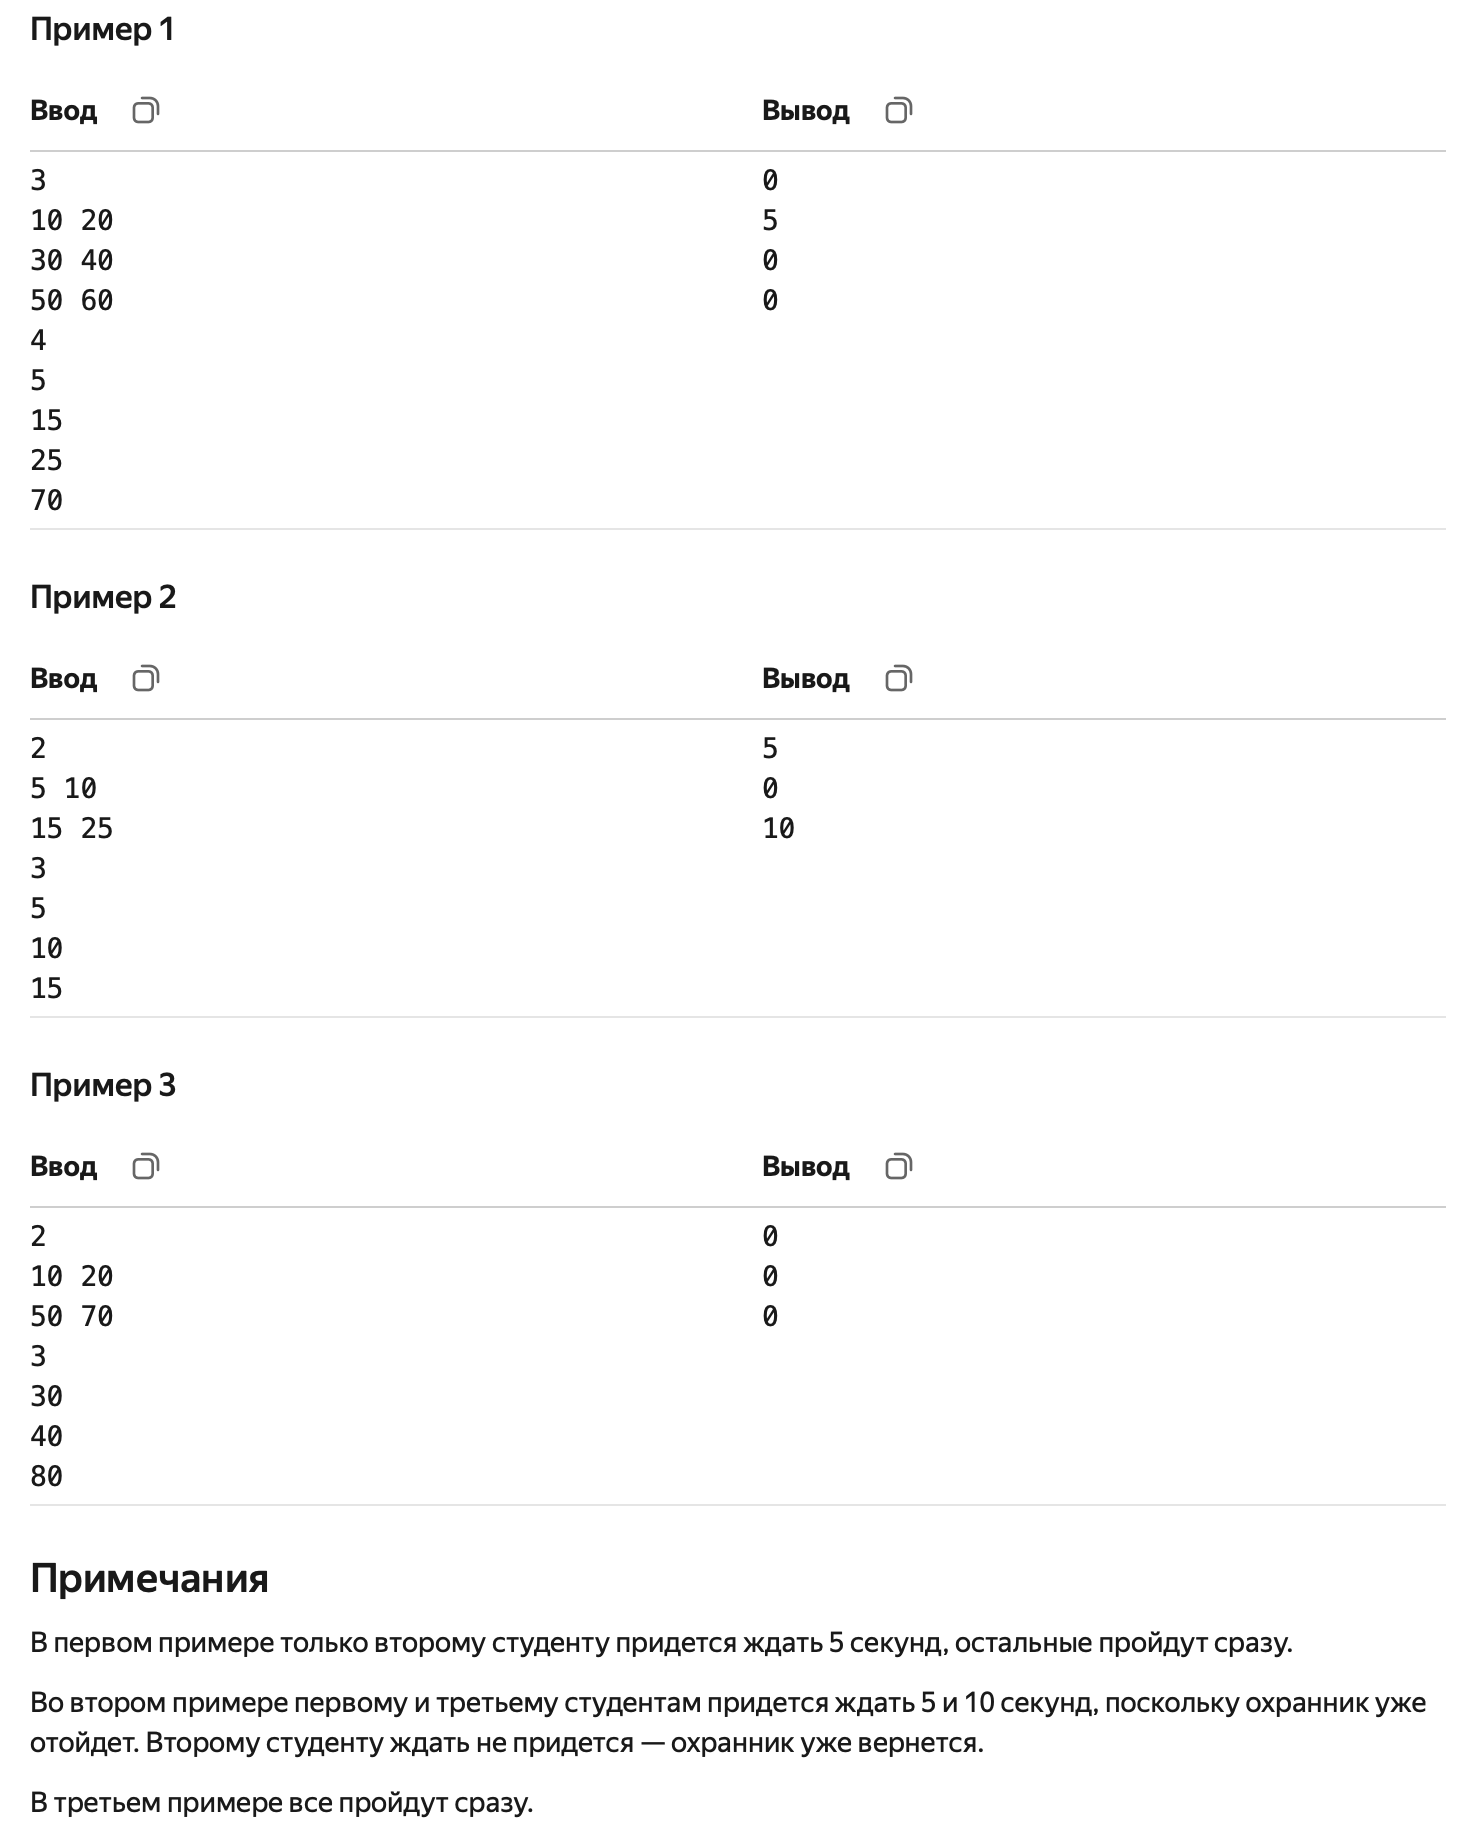

In [ ]:
# A
import sys
from bisect import bisect_right

read = sys.stdin.readline

def wait_time(x: int, intervals: list[tuple[int, int]], lefts: list[int]) -> int:
    WaitTime = 0

    pos = bisect_right(lefts, x) - 1
    if pos < 0:
        return WaitTime

    l, r = intervals[pos]
    if l <= x <= r:
        WaitTime = r - x
    return WaitTime

N = int(read())
intervals = []

for _ in range(N):
    a, b = map(int, read().split())
    intervals.append((a, b))
lefts = [l for l, r in intervals]
M = int(read())
for _ in range(M):
    x = int(read())
    print(wait_time(x, intervals, lefts))



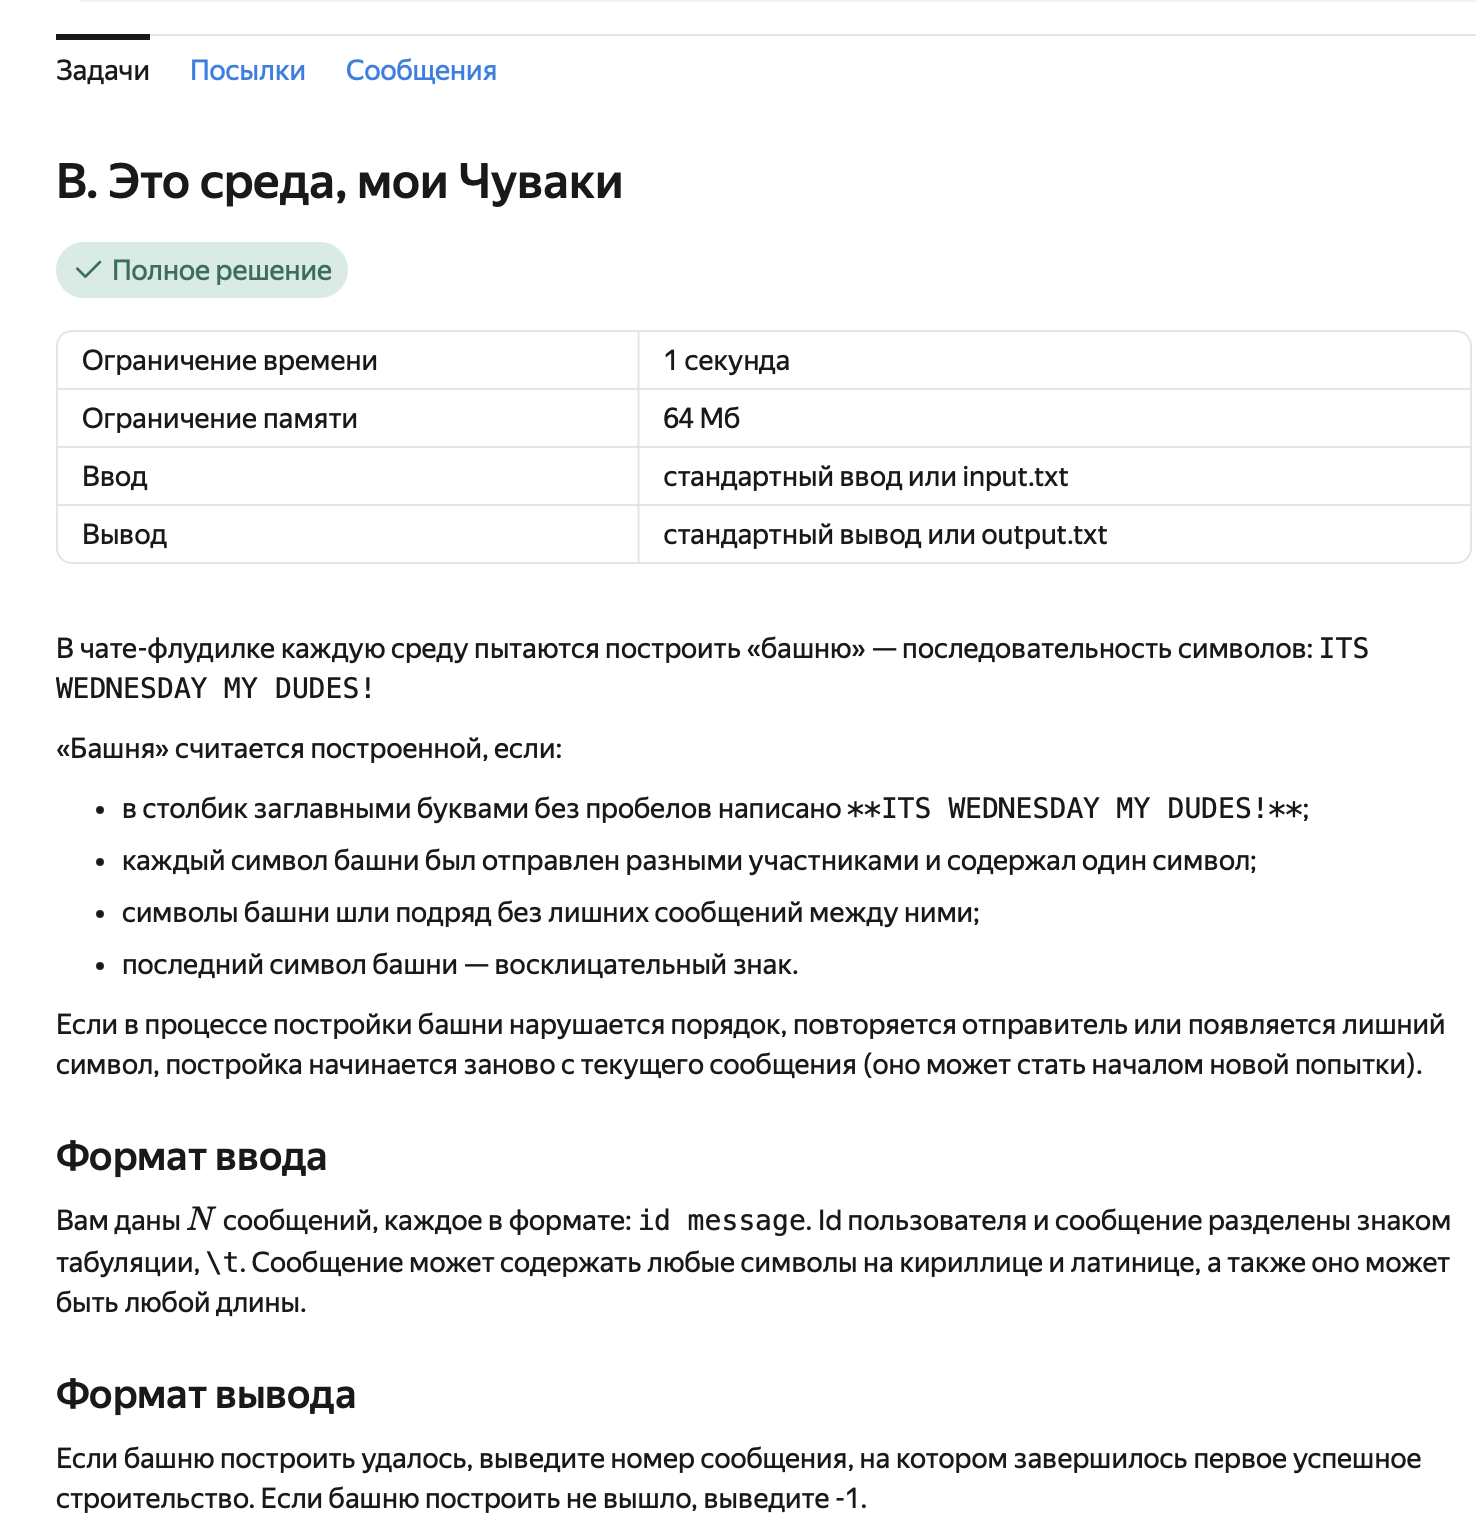

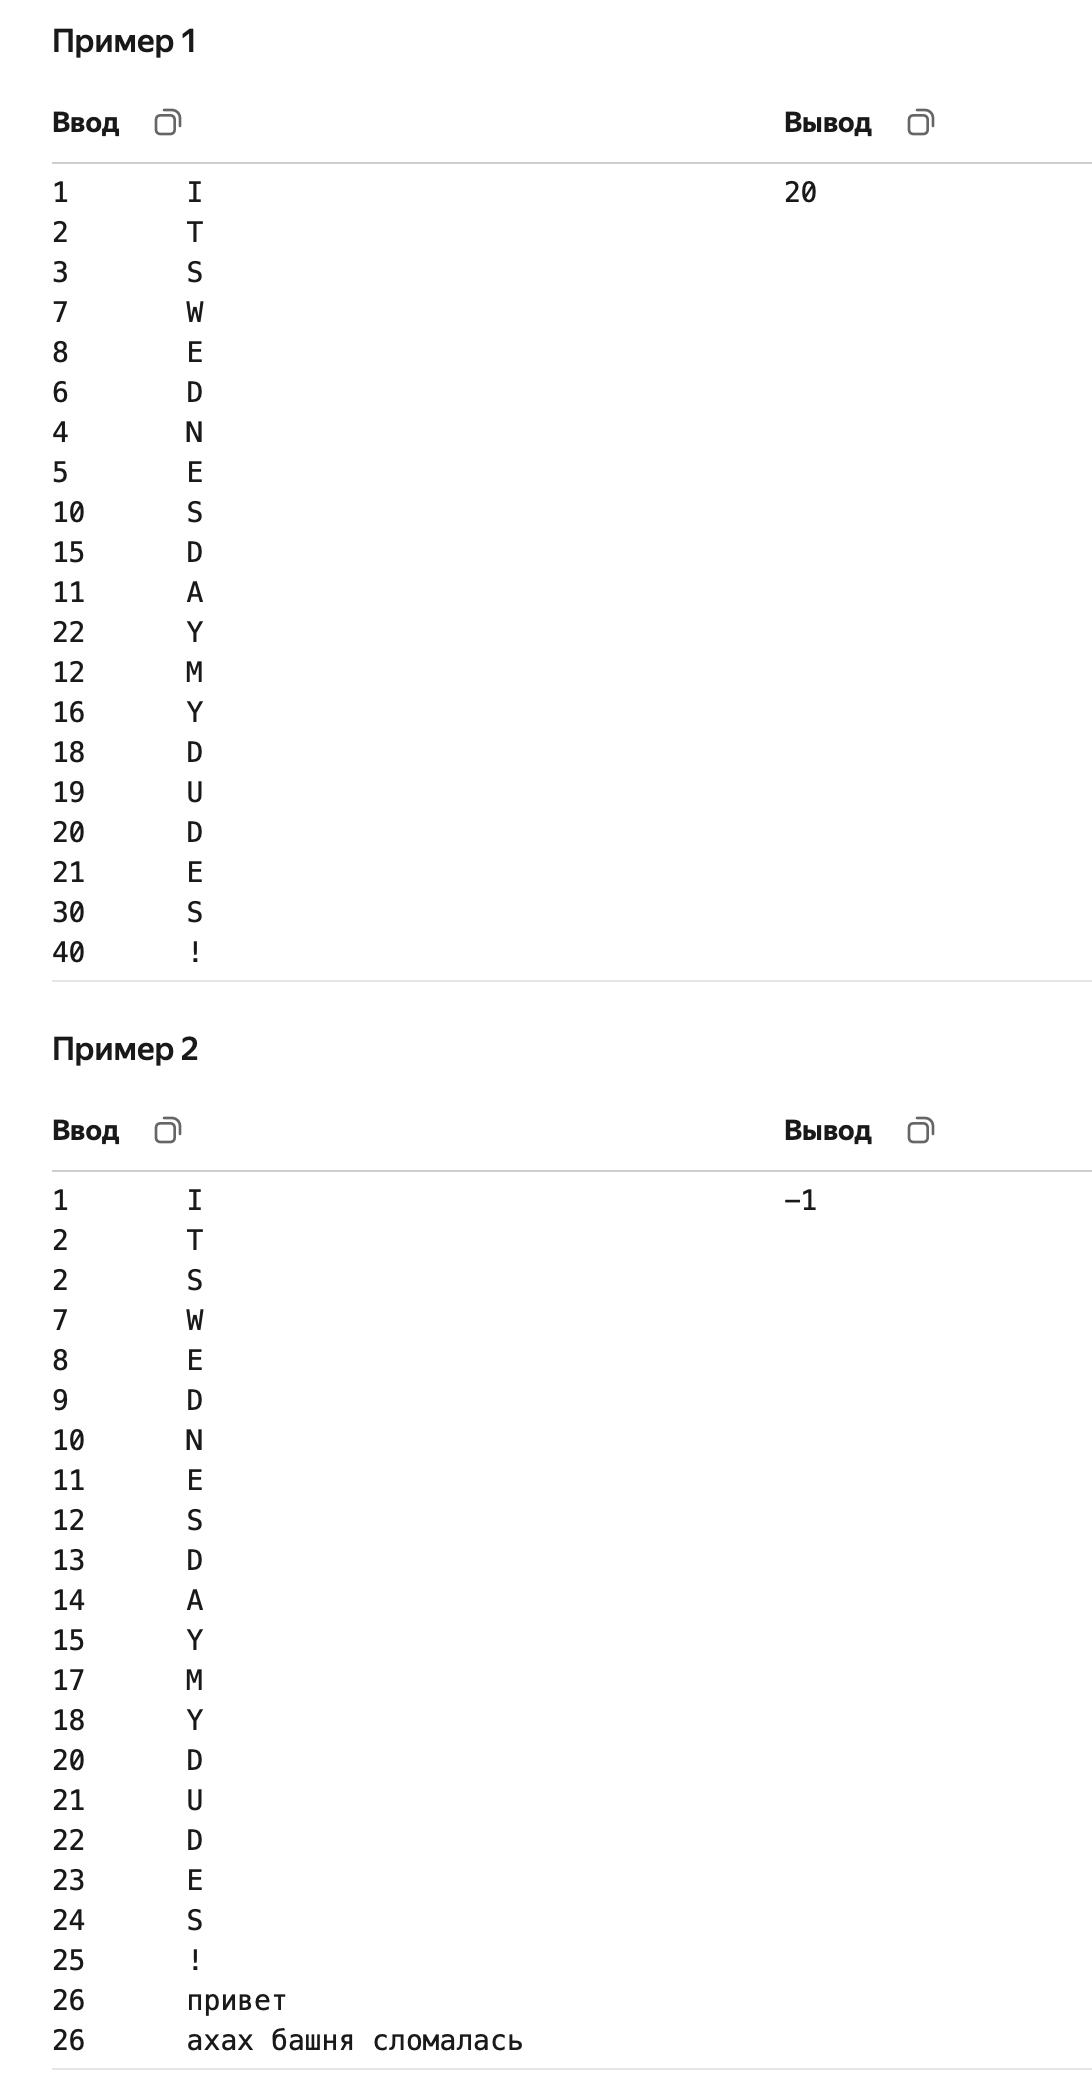

In [ ]:
# B
import sys
from collections import deque

target = "ITSWEDNESDAYMYDUDES!"
L = len(target)

ids_window = deque()   
chars_window = deque() 

message_number = 0      

for line in sys.stdin:
    message_number += 1

    line = line.rstrip('\n')
    parts = line.split('\t', 1)

    user_id, msg = parts
    ch = msg if len(msg) == 1 else '^'  
    ids_window.append(user_id)
    chars_window.append(ch)

    if len(chars_window) > L:
        ids_window.popleft()
        chars_window.popleft()

    if len(chars_window) == L:
        if ''.join(chars_window) == target and len(set(ids_window)) == L:
            print(message_number)
            sys.exit(0)

print(-1)

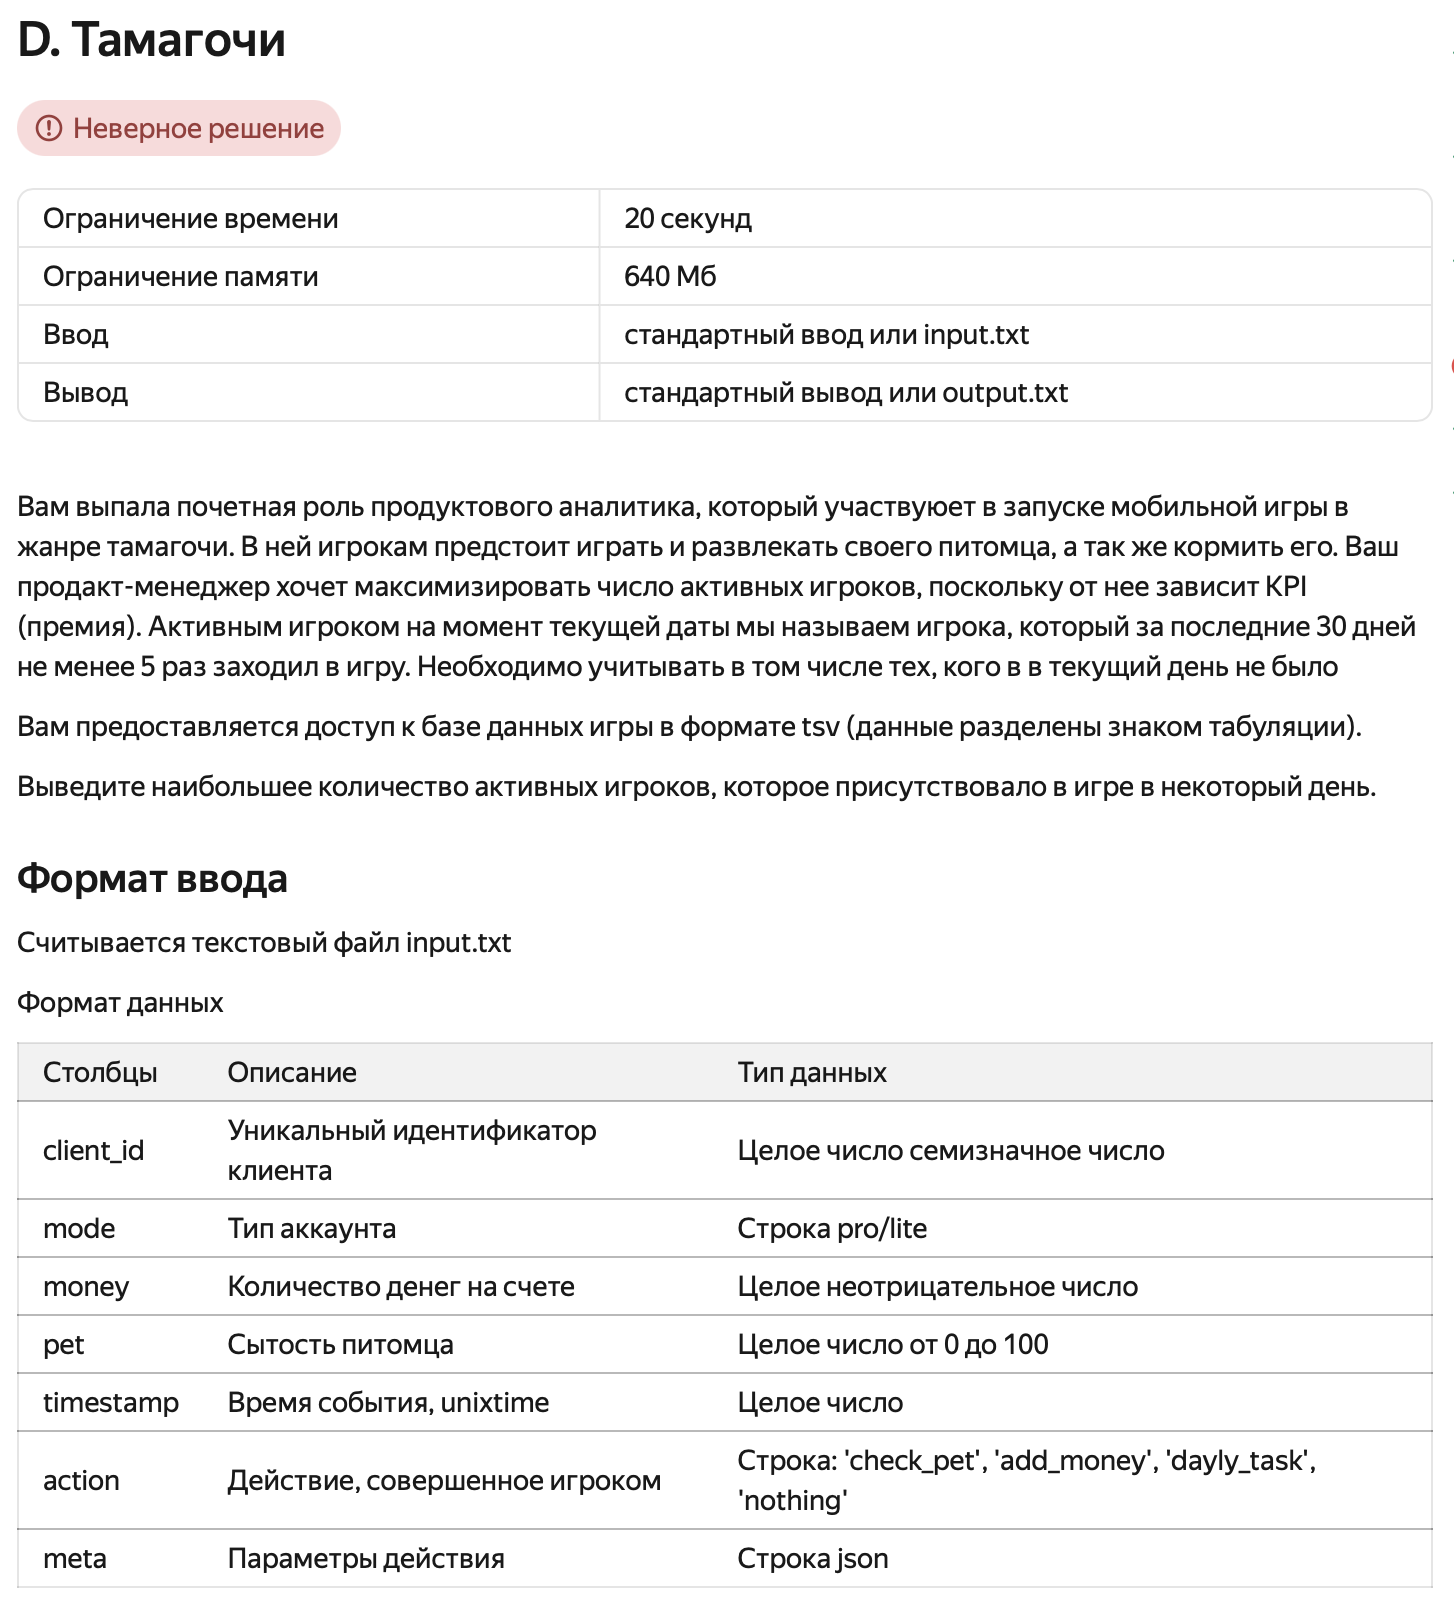

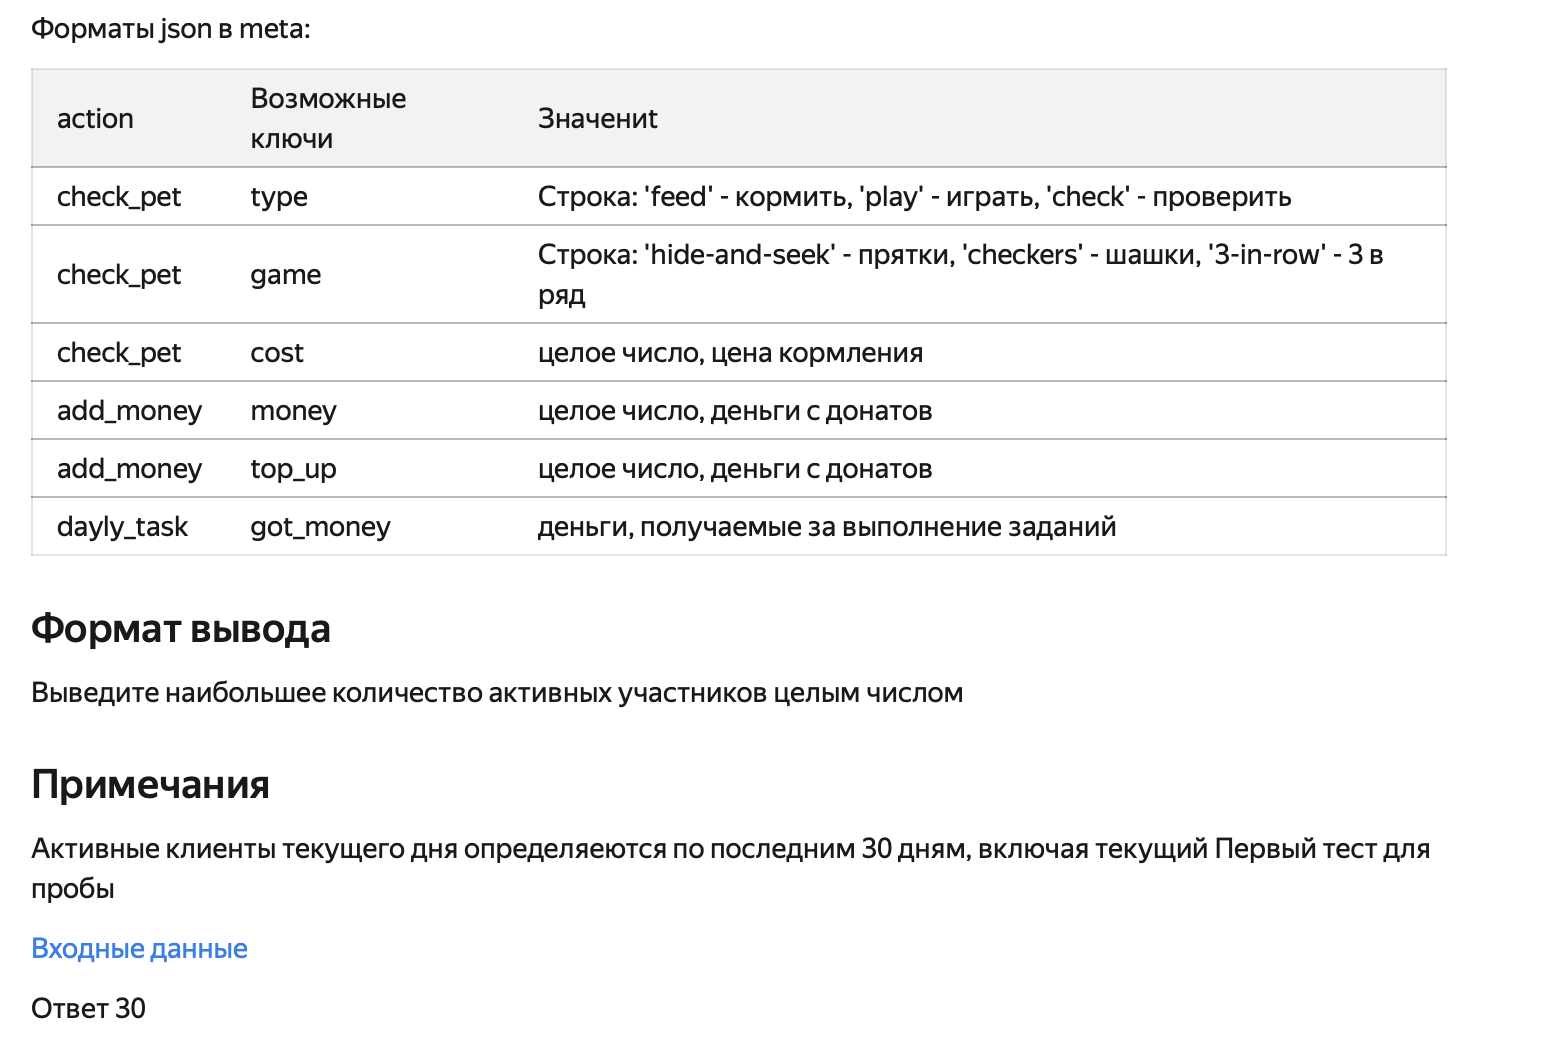

In [ ]:
# D
import pandas as pd

df = pd.read_csv("input.txt", sep=";")

df["date"] = pd.to_datetime(df["timestamp"], unit="s").dt.floor("D")

visits = (
    df.groupby(["client_id", "date"])
    .size()
    .reset_index(name="events")
)
visits["visit"] = 1

table = (
    visits.pivot_table(
        index="client_id",
        columns="date",
        values="visit",
        aggfunc="max",
        fill_value=0,
    )
    .sort_index(axis=1)
)

window_size = 30
required_visits = 5

rolling = table.T.rolling(window=window_size, min_periods=1).sum().T

active_mask = rolling >= required_visits

present_mask = table > 0

active_and_present_per_day = (active_mask & present_mask).sum(axis=0)

print(int(active_and_present_per_day.max()))

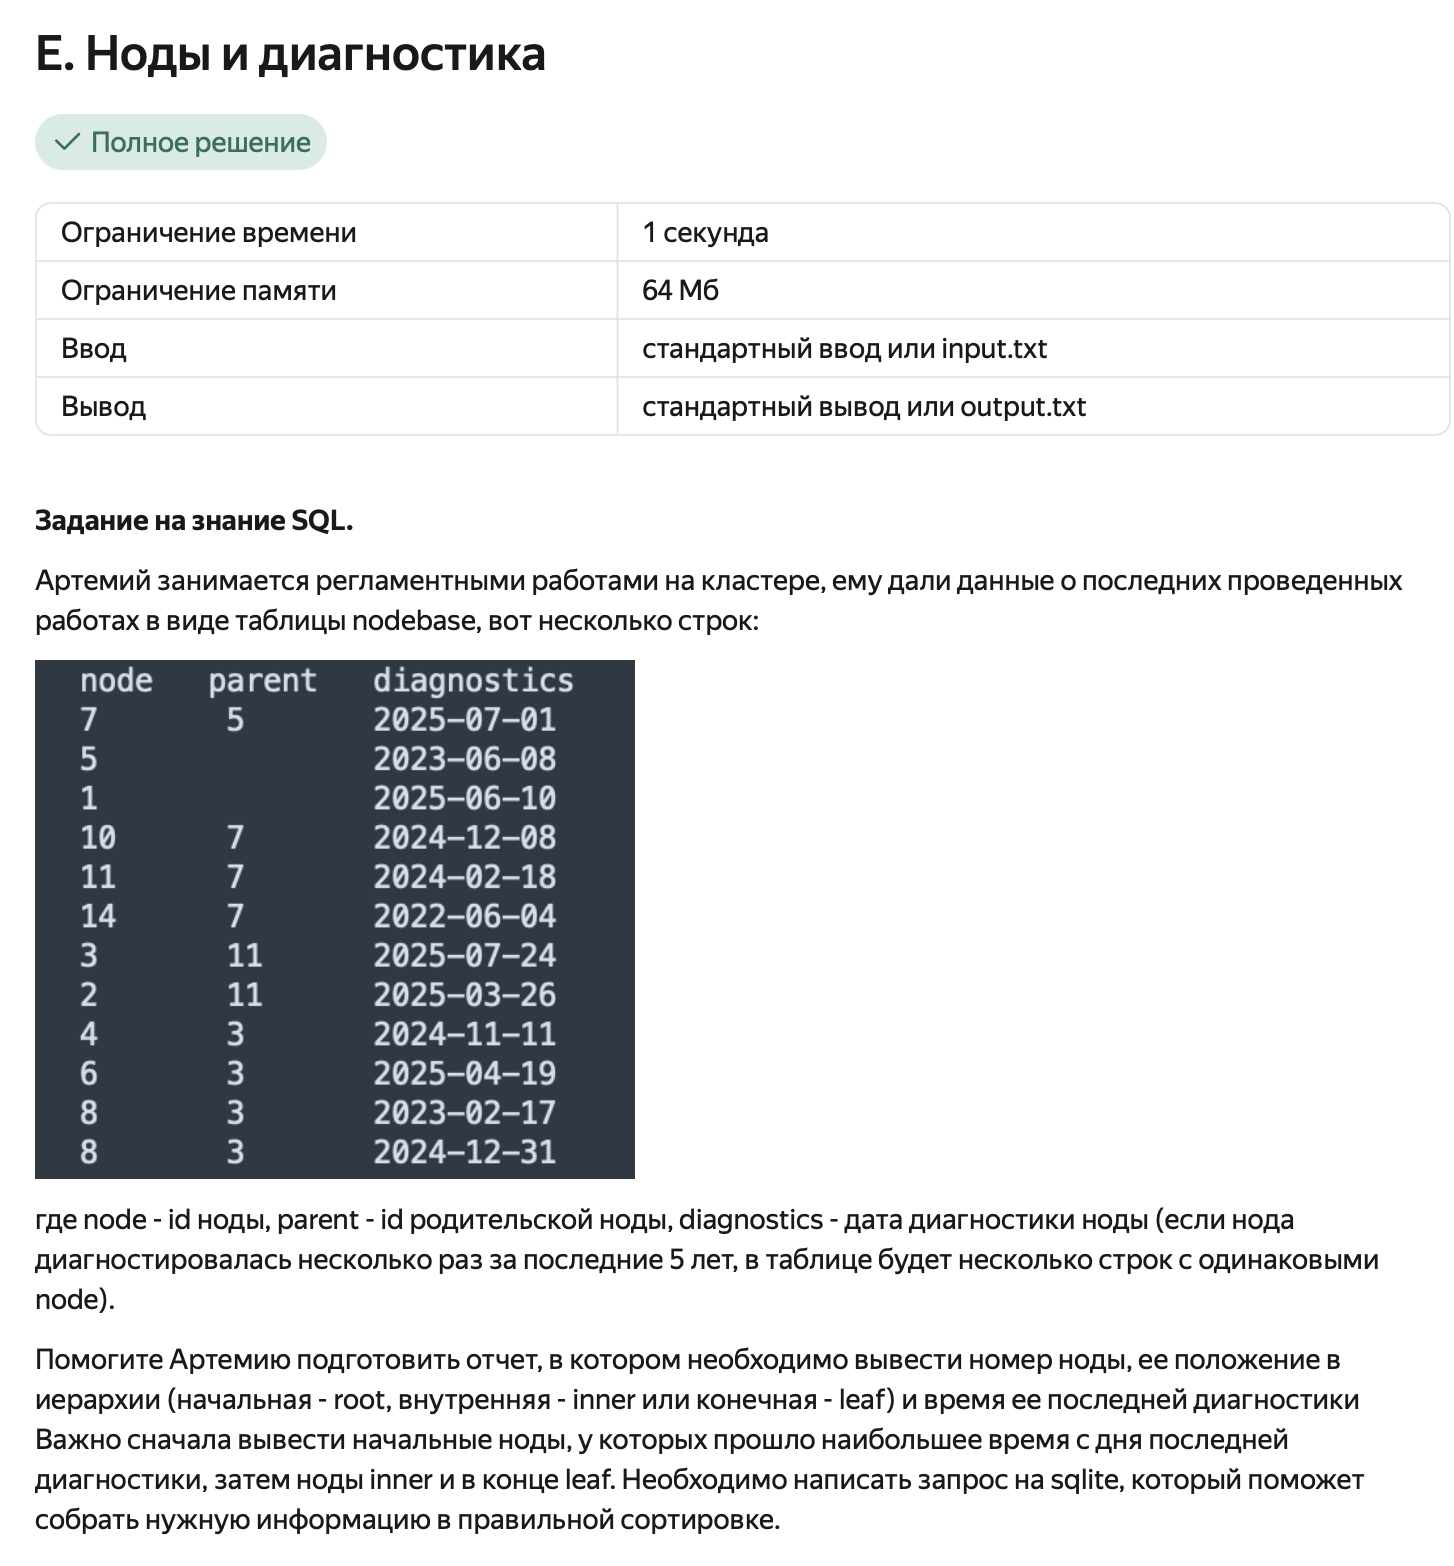

In [ ]:
# E
# WITH last_diag AS (
#     SELECT
#         node,
#         parent,
#         MAX(diagnostics) AS last_diagnostics
#     FROM nodebase
#     GROUP BY node
# ),

# children AS (
#     SELECT DISTINCT parent AS node
#     FROM nodebase
#     WHERE parent IS NOT NULL
# )

# SELECT
#     ld.node,
#     CASE
#         WHEN ld.parent IS NULL THEN 'root'
#         WHEN c.node IS NULL THEN 'leaf'
#         ELSE 'inner'
#     END AS position,
#     ld.last_diagnostics
# FROM last_diag ld
# LEFT JOIN children c
#     ON ld.node = c.node
# ORDER BY
#     CASE
#         WHEN ld.parent IS NULL THEN 1
#         WHEN c.node IS NOT NULL THEN 2
#         ELSE 3
#     END,
#     ld.last_diagnostics ASC;


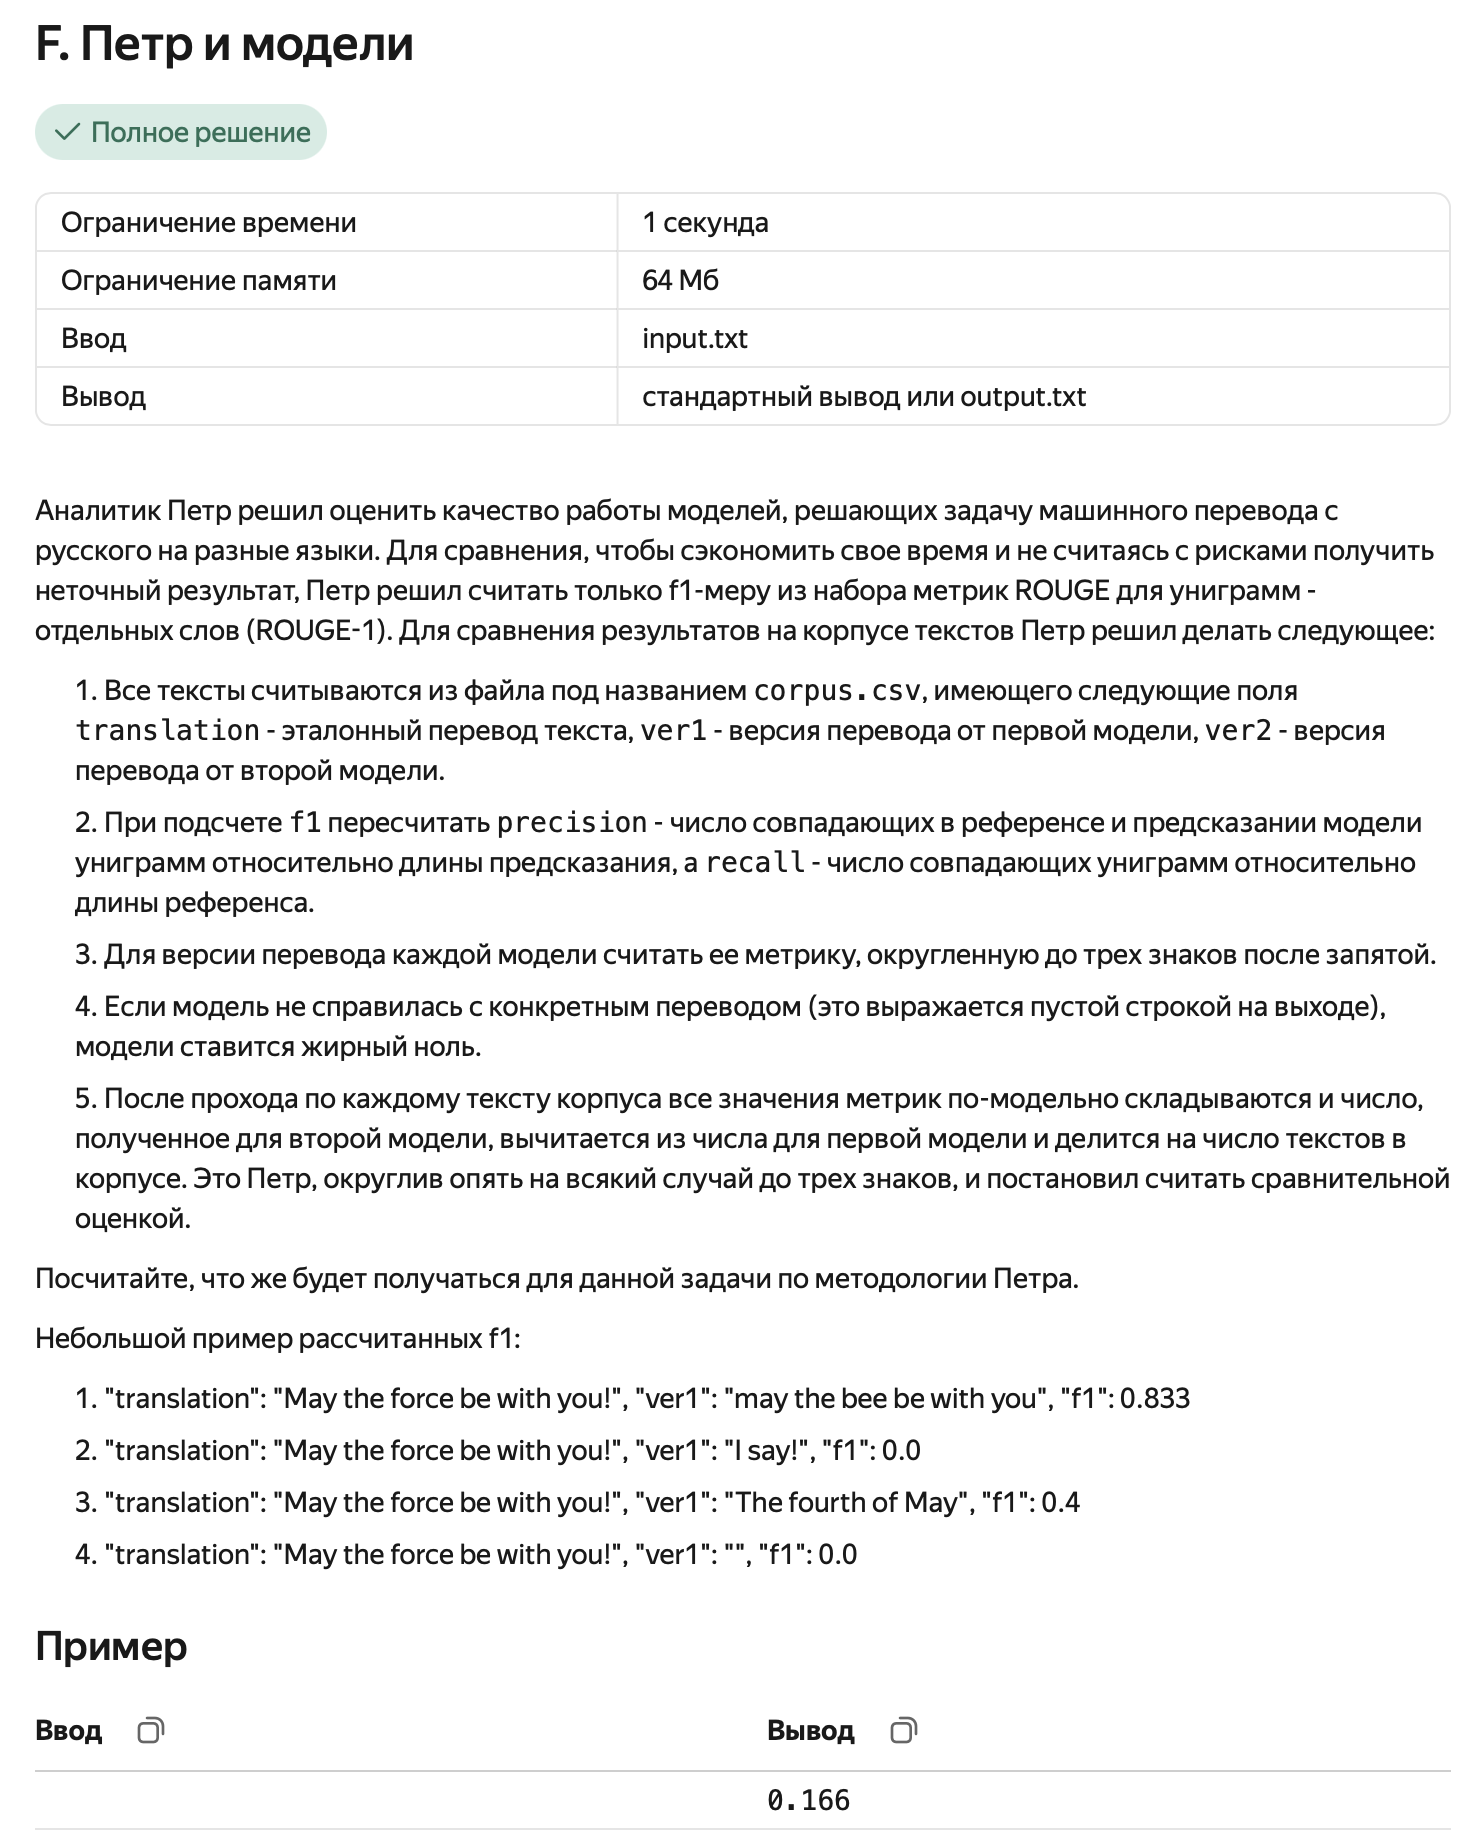

In [ ]:
# F
import csv
import re
from collections import Counter

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

def rouge1_f1(reference, prediction):
    if not prediction.strip():
        return 0.0

    ref_tokens = tokenize(reference)
    pred_tokens = tokenize(prediction)

    ref_cnt = Counter(ref_tokens)
    pred_cnt = Counter(pred_tokens)

    overlap = sum((ref_cnt & pred_cnt).values())
    if overlap == 0:
        return 0.0

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)

    return 2 * precision * recall / (precision + recall)

sum_ver1 = 0.0
sum_ver2 = 0.0
n_texts = 0

with open("corpus.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        ref = row["translation"]
        v1 = row["ver1"]
        v2 = row["ver2"]

        f1_v1 = round(rouge1_f1(ref, v1), 3)
        f1_v2 = round(rouge1_f1(ref, v2), 3)

        sum_ver1 += f1_v1
        sum_ver2 += f1_v2
        n_texts += 1

result = round((sum_ver1 - sum_ver2) / n_texts, 3)
print(f"{result:.3f}")
